# Re-evaluación MBNTv3S_ssdlite_v1

Este notebook re-ejecuta la evaluación del modelo MobileNetV3-Small SSD-Lite
entrenado en Vertex AI, usando la función `evaluate_mobilenet_model` corregida
que **deduplica** los ground-truths a nivel de anchor.

**No requiere re-entrenamiento.** Usa los artefactos descargados:
- Modelo: `outputs/MBNTv3S_ssdlite_v1/MBNTv3S_ssdlite_v1_final.keras`
- TFLite: `outputs/MBNTv3S_ssdlite_v1/tflite/MBNTv3S_ssdlite_v1_int8.tflite`
- Dataset: `datasets/tfrecord/`

In [1]:
import os, sys, json
import numpy as np

# Paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

OUTPUTS_DIR = os.path.join(PROJECT_ROOT, "outputs", "MBNTv3S_ssdlite_v1")
DATASET_DIR = os.path.join(os.path.dirname(PROJECT_ROOT), "datasets", "tfrecord")
MODEL_PATH  = os.path.join(OUTPUTS_DIR, "MBNTv3S_ssdlite_v1_final.keras")
TFLITE_PATH = os.path.join(OUTPUTS_DIR, "tflite", "MBNTv3S_ssdlite_v1_int8.tflite")

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset dir:  {DATASET_DIR}")
print(f"Model:        {MODEL_PATH}  exists={os.path.exists(MODEL_PATH)}")
print(f"TFLite:       {TFLITE_PATH}  exists={os.path.exists(TFLITE_PATH)}")

Project root: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI
Dataset dir:  /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/tfrecord
Model:        /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/MBNTv3S_ssdlite_v1/MBNTv3S_ssdlite_v1_final.keras  exists=True
TFLite:       /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/MBNTv3S_ssdlite_v1/tflite/MBNTv3S_ssdlite_v1_int8.tflite  exists=True


In [2]:
# Configuración del experimento (mismos valores que el YAML de Vertex AI)
CLASS_NAMES = ["dog", "door", "obstacle", "person", "stair"]
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = len(CLASS_NAMES)

# Anchors — misma config que mobilenet_v3s_ssdlite_v1.yaml
ANCHOR_SIZES = [0.1, 0.2, 0.37, 0.54, 0.71, 0.88]
ANCHOR_RATIOS = [1.0, 2.0, 0.5, 3.0, 0.33]

print(f"Classes: {CLASS_NAMES}")
print(f"Img size: {IMG_SIZE}")
print(f"Anchors: {len(ANCHOR_SIZES)} sizes × {len(ANCHOR_RATIOS)} ratios")

Classes: ['dog', 'door', 'obstacle', 'person', 'stair']
Img size: 224
Anchors: 6 sizes × 5 ratios


## 1. Generar anchors y crear pipeline de evaluación

In [3]:
from src_colab import generate_anchors, compute_anchor_statistics, create_mobilenet_pipeline

anchors = generate_anchors(
    imgsz=IMG_SIZE,
    sizes=ANCHOR_SIZES,
    ratios=ANCHOR_RATIOS,
)
compute_anchor_statistics(anchors)

# Pipelines de val y test (sin augmentation, sin shuffle)
val_ds = create_mobilenet_pipeline(
    dataset_dir=DATASET_DIR, split="val", anchors=anchors,
    class_names=CLASS_NAMES, batch_size=BATCH_SIZE, imgsz=IMG_SIZE,
    augment_level="none", shuffle=False,
)
test_ds = create_mobilenet_pipeline(
    dataset_dir=DATASET_DIR, split="test", anchors=anchors,
    class_names=CLASS_NAMES, batch_size=BATCH_SIZE, imgsz=IMG_SIZE,
    augment_level="none", shuffle=False,
)
print(f"\n✅ val_ds: {val_ds}")
print(f"✅ test_ds: {test_ds}")

⚓ Anchors: 1470  |  W: [0.057, 1.524]  |  H: [0.058, 1.532]
📂 Pipeline val: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/tfrecord/val.tfrecord


2026-02-08 14:32:25.334189: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-02-08 14:32:25.334347: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-02-08 14:32:25.334350: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1770579145.334674 1090475 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1770579145.335024 1090475 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


📂 Pipeline test: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/tfrecord/test.tfrecord

✅ val_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), {'objectness': TensorSpec(shape=(None, 1470, 1), dtype=tf.float32, name=None), 'class_out': TensorSpec(shape=(None, 1470, 5), dtype=tf.float32, name=None), 'bbox_out': TensorSpec(shape=(None, 1470, 4), dtype=tf.float32, name=None)})>
✅ test_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), {'objectness': TensorSpec(shape=(None, 1470, 1), dtype=tf.float32, name=None), 'class_out': TensorSpec(shape=(None, 1470, 5), dtype=tf.float32, name=None), 'bbox_out': TensorSpec(shape=(None, 1470, 4), dtype=tf.float32, name=None)})>


## 2. Cargar modelo entrenado (.keras)

In [4]:
import tensorflow as tf
from src_colab.utils_train import _focal_loss, _binary_focal_loss, _smooth_l1_loss

# Registrar custom losses para poder cargar el .keras
custom_objects = {
    "fn": _binary_focal_loss(0.25, 2.0),     # objectness
    "focal_loss": _focal_loss(0.25, 2.0),     # class_out  
    "smooth_l1": _smooth_l1_loss(1.0),         # bbox_out
}

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print(f"✅ Modelo cargado: {model.name}")
print(f"   Parámetros: {model.count_params():,}")
print(f"   Input:  {model.input_shape}")
print(f"   Output: {[model.output[k].shape for k in model.output]}")

✅ Modelo cargado: MobileNetV3S_SSDLite
   Parámetros: 579,988
   Input:  (None, 224, 224, 3)
   Output: [(None, 1470, 1), (None, 1470, 5), (None, 1470, 4)]


## 3. Re-evaluación Framework (Val + Test) — con fix de deduplicación

In [5]:
from src_colab import evaluate_mobilenet_model, save_evaluation

# Validación
val_ev = evaluate_mobilenet_model(
    model=model,
    val_ds=val_ds,
    class_names=CLASS_NAMES,
    imgsz=IMG_SIZE,
    anchors=anchors,
    model_name="MBNTv3S_ssdlite_v1",
)
val_ev.split = "val"

print(f"\n{'='*60}")
print(f"n_ground_truths: {val_ev.n_ground_truths}  (antes era ~197K, ahora debería ser ~3.8K)")
print(f"n_detections:    {val_ev.n_detections}")

2026-02-08 14:33:26.489886: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144



📊 Evaluación: MBNTv3S_ssdlite_v1 (mobilenet) – split=val
  mAP@50:    0.3299
  mAP@50-95: 0.0000
  Precision: 0.1569
  Recall:    0.5130
  F1-Score:  0.2404
  Imágenes: 2066  |  Detecciones: 13451  |  GT: 4032
  Avg inference: 3.5 ms

  Per-class AP@50:
    dog                   0.3525
    door                  0.3880
    obstacle              0.1800
    person                0.0880
    stair                 0.6408

n_ground_truths: 4032  (antes era ~197K, ahora debería ser ~3.8K)
n_detections:    13451


2026-02-08 14:33:34.378459: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
# Test
test_ev = evaluate_mobilenet_model(
    model=model,
    val_ds=test_ds,
    class_names=CLASS_NAMES,
    imgsz=IMG_SIZE,
    anchors=anchors,
    model_name="MBNTv3S_ssdlite_v1",
)
test_ev.split = "test"

print(f"\n{'='*60}")
print(f"n_ground_truths: {test_ev.n_ground_truths}")
print(f"n_detections:    {test_ev.n_detections}")


📊 Evaluación: MBNTv3S_ssdlite_v1 (mobilenet) – split=val
  mAP@50:    0.3263
  mAP@50-95: 0.0000
  Precision: 0.1583
  Recall:    0.5245
  F1-Score:  0.2432
  Imágenes: 2066  |  Detecciones: 13700  |  GT: 4056
  Avg inference: 2.8 ms

  Per-class AP@50:
    dog                   0.3943
    door                  0.3711
    obstacle              0.1852
    person                0.1056
    stair                 0.5751

n_ground_truths: 4056
n_detections:    13700


2026-02-08 14:34:11.214077: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 4. Re-evaluación TFLite (Test)

In [7]:
from src_colab import evaluate_tflite_model

tflite_test_ev = evaluate_tflite_model(
    tflite_path=TFLITE_PATH,
    class_names=CLASS_NAMES,
    imgsz=IMG_SIZE,
    conf_threshold=0.25,
    iou_threshold=0.5,
    model_name="MBNTv3S_ssdlite_v1_tflite",
    test_ds=test_ds,
)

print(f"\n{'='*60}")
print(f"TFLite n_ground_truths: {tflite_test_ev.n_ground_truths}")
print(f"TFLite n_detections:    {tflite_test_ev.n_detections}")

/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/env/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.



📊 Evaluación: MBNTv3S_ssdlite_v1_tflite (tflite) – split=test
  mAP@50:    0.2552
  mAP@50-95: 0.0000
  Precision: 0.1338
  Recall:    0.4338
  F1-Score:  0.2046
  Imágenes: 2066  |  Detecciones: 12509  |  GT: 4056
  Avg inference: 0.9 ms

  Per-class AP@50:
    dog                   0.3335
    door                  0.2401
    obstacle              0.1298
    person                0.0741
    stair                 0.4984

TFLite n_ground_truths: 4056
TFLite n_detections:    12509


## 5. Comparación: Antes vs Después del fix + YOLO26

In [8]:
# Cargar resultados originales (con bug) para comparar
with open(os.path.join(OUTPUTS_DIR, "test_evaluation.json")) as f:
    old_test = json.load(f)

# Cargar YOLO26 para referencia
yolo_path = os.path.join(PROJECT_ROOT, "outputs", "yolo26n_v1", "experiment.json")
if os.path.exists(yolo_path):
    with open(yolo_path) as f:
        yolo_res = json.load(f)["results"]
else:
    yolo_res = None

# Tabla comparativa
print(f"{'Métrica':<25s} {'MBN (bug)':>12s} {'MBN (fix)':>12s} {'YOLO26':>12s}")
print("-" * 63)
metrics = [
    ("n_ground_truths", old_test["n_ground_truths"], test_ev.n_ground_truths, "-"),
    ("n_detections", old_test["n_detections"], test_ev.n_detections, "-"),
    ("test_mAP50", old_test["mAP50"], test_ev.mAP50, yolo_res["test_mAP50"] if yolo_res else "-"),
    ("test_mAP50_95", old_test["mAP50_95"], test_ev.mAP50_95, yolo_res["test_mAP50_95"] if yolo_res else "-"),
    ("test_precision", old_test["precision"], test_ev.precision, yolo_res["test_precision"] if yolo_res else "-"),
    ("test_recall", old_test["recall"], test_ev.recall, yolo_res["test_recall"] if yolo_res else "-"),
    ("test_f1", old_test["f1"], test_ev.f1, yolo_res["test_f1"] if yolo_res else "-"),
]
for name, old_v, new_v, yolo_v in metrics:
    def fmt(v):
        return f"{v:>12.4f}" if isinstance(v, float) else f"{str(v):>12s}"
    print(f"  {name:<23s} {fmt(old_v)} {fmt(new_v)} {fmt(yolo_v)}")

print(f"\n  Per-class AP@50 (test, corregido):")
for cls_name, ap in sorted(test_ev.per_class_ap50.items()):
    yolo_ap = yolo_res["test_per_class_ap50"].get(cls_name, 0) if yolo_res else 0
    print(f"    {cls_name:12s}  MBN={ap:.4f}  YOLO={yolo_ap:.4f}")

Métrica                      MBN (bug)    MBN (fix)       YOLO26
---------------------------------------------------------------
  n_ground_truths               195412         4056            -
  n_detections                   13701        13700            -
  test_mAP50                    0.0127       0.3263       0.7932
  test_mAP50_95                 0.0000       0.0000       0.5978
  test_precision                0.1583       0.1583       0.8228
  test_recall                   0.0141       0.5245       0.6989
  test_f1                       0.0259       0.2432       0.7558

  Per-class AP@50 (test, corregido):
    dog           MBN=0.3943  YOLO=0.7643
    door          MBN=0.3711  YOLO=0.9045
    obstacle      MBN=0.1852  YOLO=0.7465
    person        MBN=0.1056  YOLO=0.7113
    stair         MBN=0.5751  YOLO=0.8392


## 6. Guardar resultados corregidos

💾 Evaluación guardada: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/MBNTv3S_ssdlite_v1/corrected/val_evaluation.json
💾 Evaluación guardada: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/MBNTv3S_ssdlite_v1/corrected/test_evaluation.json
💾 Evaluación guardada: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/MBNTv3S_ssdlite_v1/corrected/tflite_test_evaluation.json
📊 Confusion matrix guardada: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/MBNTv3S_ssdlite_v1/corrected/test_confusion_matrix.png


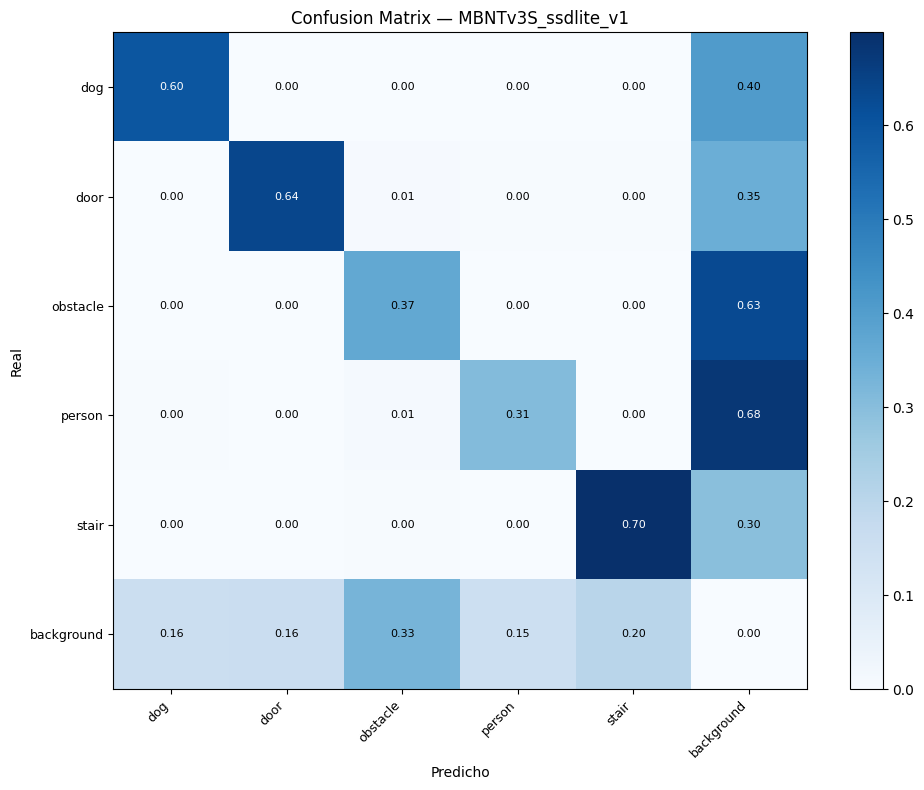

📊 Per-class metrics guardados: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/MBNTv3S_ssdlite_v1/corrected/test_per_class.png


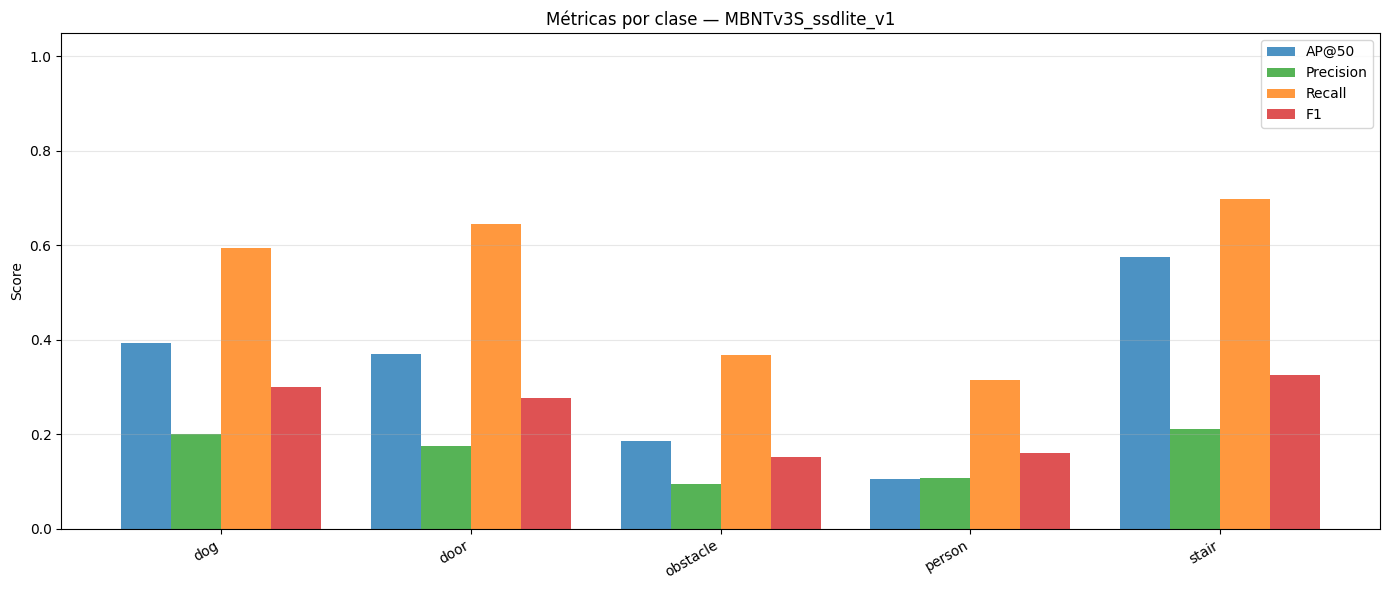

📊 Confusion matrix guardada: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/MBNTv3S_ssdlite_v1/corrected/tflite_test_confusion_matrix.png


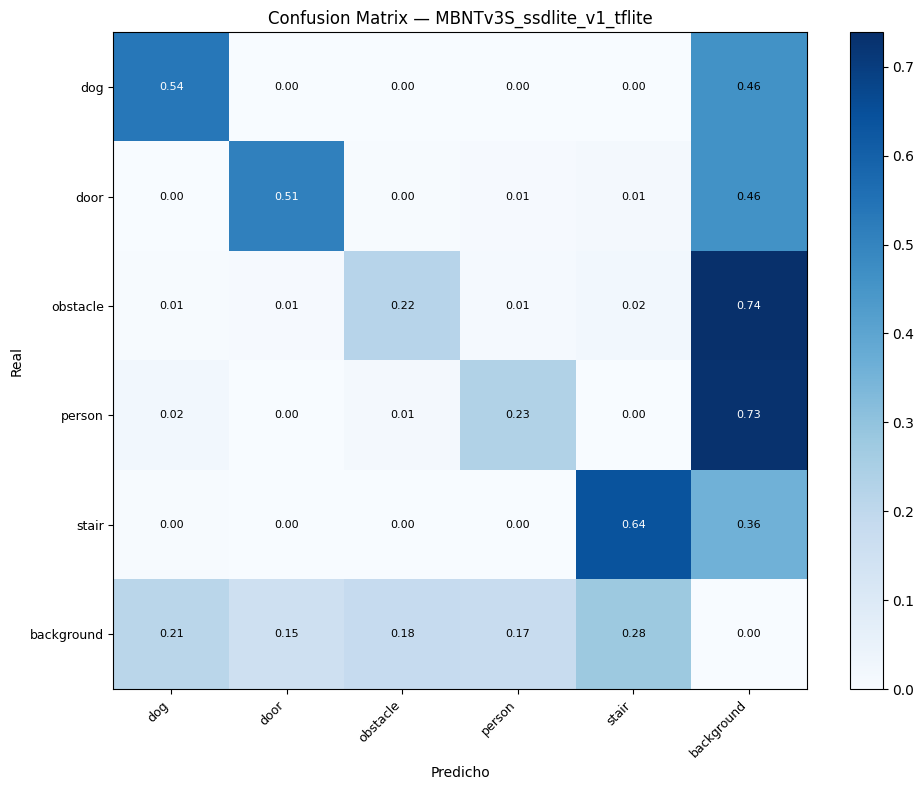

📊 Per-class metrics guardados: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/MBNTv3S_ssdlite_v1/corrected/tflite_test_per_class.png


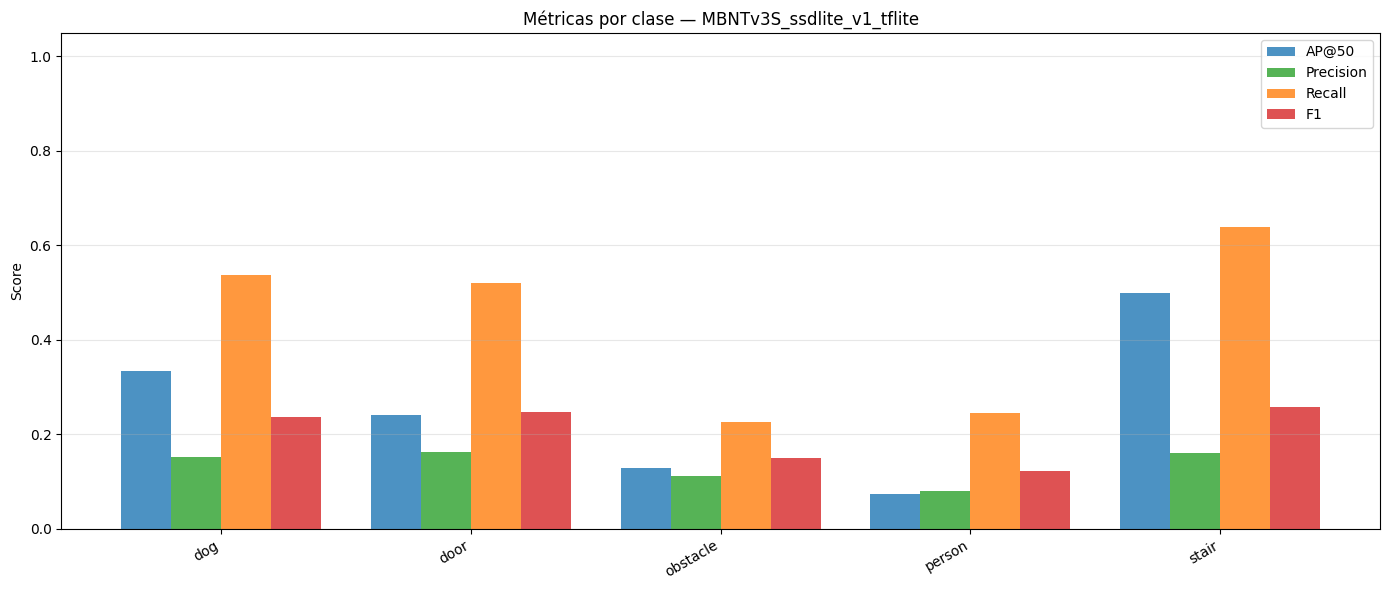


✅ Resultados corregidos guardados en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/MBNTv3S_ssdlite_v1/corrected
   Archivos: ['tflite_test_evaluation.json', 'test_evaluation.json', 'val_evaluation.json', 'test_confusion_matrix.png', 'tflite_test_per_class.png', 'test_per_class.png', 'tflite_test_confusion_matrix.png']


In [9]:
from src_colab import plot_confusion_matrix, plot_per_class_metrics

# Guardar evaluaciones corregidas
corrected_dir = os.path.join(OUTPUTS_DIR, "corrected")
os.makedirs(corrected_dir, exist_ok=True)

save_evaluation(val_ev, os.path.join(corrected_dir, "val_evaluation.json"))
save_evaluation(test_ev, os.path.join(corrected_dir, "test_evaluation.json"))
save_evaluation(tflite_test_ev, os.path.join(corrected_dir, "tflite_test_evaluation.json"))

# Confusion matrix y per-class plots
plot_confusion_matrix(test_ev, save_path=os.path.join(corrected_dir, "test_confusion_matrix.png"))
plot_per_class_metrics(test_ev, save_path=os.path.join(corrected_dir, "test_per_class.png"))

# TFLite plots
plot_confusion_matrix(tflite_test_ev, save_path=os.path.join(corrected_dir, "tflite_test_confusion_matrix.png"))
plot_per_class_metrics(tflite_test_ev, save_path=os.path.join(corrected_dir, "tflite_test_per_class.png"))

print(f"\n✅ Resultados corregidos guardados en: {corrected_dir}")
print(f"   Archivos: {os.listdir(corrected_dir)}")

## 7. Actualizar experiment.json con métricas corregidas

In [10]:
# Leer experiment.json original y actualizar con métricas corregidas
exp_path = os.path.join(OUTPUTS_DIR, "experiment.json")
with open(exp_path) as f:
    experiment = json.load(f)

r = experiment["results"]

# Val (framework)
r["val_mAP50"] = val_ev.mAP50
r["val_mAP50_95"] = val_ev.mAP50_95
r["val_precision"] = val_ev.precision
r["val_recall"] = val_ev.recall
r["val_f1"] = val_ev.f1
r["val_per_class_ap50"] = val_ev.per_class_ap50

# Test (framework)
r["test_mAP50"] = test_ev.mAP50
r["test_mAP50_95"] = test_ev.mAP50_95
r["test_precision"] = test_ev.precision
r["test_recall"] = test_ev.recall
r["test_f1"] = test_ev.f1
r["test_per_class_ap50"] = test_ev.per_class_ap50

# TFLite test
r["tflite_test_mAP50"] = tflite_test_ev.mAP50
r["tflite_test_mAP50_95"] = tflite_test_ev.mAP50_95
r["tflite_test_precision"] = tflite_test_ev.precision
r["tflite_test_recall"] = tflite_test_ev.recall
r["tflite_test_f1"] = tflite_test_ev.f1
r["tflite_test_per_class_ap50"] = tflite_test_ev.per_class_ap50

# Guardar versión corregida
corrected_exp_path = os.path.join(corrected_dir, "experiment.json")
with open(corrected_exp_path, "w") as f:
    json.dump(experiment, f, indent=4, default=str)

print(f"✅ experiment.json corregido guardado en: {corrected_exp_path}")
print(f"\nMétricas test corregidas:")
print(f"  mAP@50:    {r['test_mAP50']:.4f}")
print(f"  Precision: {r['test_precision']:.4f}")
print(f"  Recall:    {r['test_recall']:.4f}")
print(f"  F1:        {r['test_f1']:.4f}")

✅ experiment.json corregido guardado en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/GoogleCloudAI/outputs/MBNTv3S_ssdlite_v1/corrected/experiment.json

Métricas test corregidas:
  mAP@50:    0.3263
  Precision: 0.1583
  Recall:    0.5245
  F1:        0.2432
